# VEP Analysis

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
    
import pandas as pd
import polars as pl
import seqpro as sp
import numpy as np
import pooch
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from tempfile import TemporaryDirectory
import genvarloader as gvl

# Local code
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.utils as utils
import src.clinvar as cv

In [2]:
### Attempts to add new slots to the xarray dataset ###

# import xarray as xr

# xr_ds = xr.open_dataset(xr_ds_path, mode="a-")

# new_slots=  np.append(xr_ds.coords["slot"].data, "delta_pow2_mean")
# print(new_slots)
# xr_ds["flashzoi"].assign_coords({"slot": ("slot", new_slots)})

## Import non-null VEP results

In [69]:
import xarray as xr
xr_ds_path = os.path.join(os.path.expanduser('~'),"projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv_test/chrX.zarr")


xr_ds = xr.open_dataset(xr_ds_path)

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [73]:
xr_ds_path = os.path.join(os.path.expanduser('~'),"projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv_test/chrX.zarr")

vep_df = vp.load_vep_results(xr_ds_path=xr_ds_path, 
                             dropna_subset=["flashzoi"])
vep_df.head()

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


After filtering:
 - rows: 45882 / 438
 - sites: 1 / 438
 - samples: 2549 / 2549
 - ploid: 2 / 2
 - slots: 9 / 13


,site,sample,ploid,slot,evo2_40b,dnabert2,spliceai,evo2_7b,flashzoi,evo2_40b_base,spliceai_mm,evo2_7b_base
2650963,chrX:624528-624529_G_C,REF,0,delta_abs_mean,NaN,NaN,NaN,NaN,0.001105,NaN,NaN,NaN
2650964,chrX:624528-624529_G_C,REF,0,delta_max_max,NaN,NaN,NaN,NaN,1.347752,NaN,NaN,NaN
2650965,chrX:624528-624529_G_C,REF,0,delta_mean,NaN,NaN,NaN,NaN,0.000560,NaN,NaN,NaN
2650966,chrX:624528-624529_G_C,REF,0,delta_pow2_mean,NaN,NaN,NaN,NaN,0.000078,NaN,NaN,NaN
2650967,chrX:624528-624529_G_C,REF,0,len_seq_mut,NaN,NaN,NaN,NaN,262144.000000,NaN,NaN,NaN


## Estimate total time

Based on the existing results, estimate how long it will take to run all selected ClinVar variants. 

In [74]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz", simplify=True) 
va.estimate_runtime(vep_df,
                     total_sites=bed_utr["name"].n_unique(),
                     model_name="flashzoi",
                     time_col="time_total",
                     n_gpus=1)

3.22 minutes per site
Number of days it should take to run all 13771 sites genome-wide:
30.81


Count the number of samples per site (should be all identical). 

In [29]:
vep_df.groupby("site")["sample"].nunique().describe()

count      68.0
mean     2549.0
std         0.0
min      2549.0
25%      2549.0
50%      2549.0
75%      2549.0
max      2549.0
Name: sample, dtype: float64

In [30]:
vep_df.groupby("slot")["flashzoi"].describe()

,count,mean,std,min,25%,50%,75%,max
slot,,,,,,,,
delta_abs_mean,346596.0,0.000457,0.000382,0.000000,0.000262,0.000387,0.000547,0.003089
delta_mean,346596.0,-0.000020,0.000200,-0.001374,-0.000080,0.000000,0.000086,0.000676
delta_pow2_mean,346596.0,0.000015,0.000041,0.000000,0.000002,0.000005,0.000011,0.001387
len_seq_mut,346596.0,262144.000000,0.000000,262144.000000,262144.000000,262144.000000,262144.000000,262144.000000
len_seq_wt,346596.0,262144.000000,0.000000,262144.000000,262144.000000,262144.000000,262144.000000,262144.000000
output_length,346596.0,262144.000000,0.000000,262144.000000,262144.000000,262144.000000,262144.000000,262144.000000
time_run_vep,346596.0,0.105911,0.267246,0.103119,0.104587,0.104814,0.105105,157.407937
time_total,346596.0,0.110424,0.267490,0.107345,0.108948,0.109229,0.109590,157.527847


Plot a sampling of the various slot values, including different VEP metrics and metadata about how long each iteration took to run.

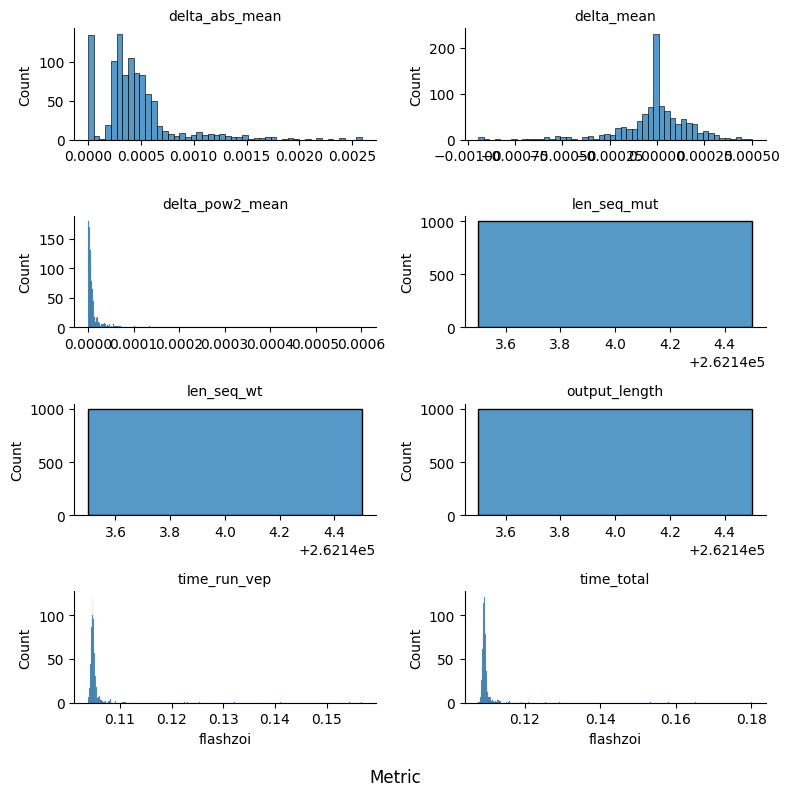

In [33]:
def summary_histograms(vep_df,
                       slot_col="slot", 
                       x="flashzoi",
                       height=2,
                       aspect=2, 
                       col_wrap=2,
                       margin_titles=True,
                       sharex=False,
                       sharey=False, 
                       sample_size=1000):

    # Create a figure with subplots for each slot
    g = sns.FacetGrid(vep_df.groupby(slot_col).sample(sample_size).sort_values(slot_col),
                    col=slot_col,  # Changed from row to col
                    col_wrap=col_wrap,  # Added col_wrap to wrap facets
                    height=height, 
                    aspect=aspect, 
                    margin_titles=margin_titles,
                    sharex=sharex, 
                    sharey=sharey)
    g.map_dataframe(sns.histplot, x=x)
    g.set_titles("{col_name}")
    g.fig.supxlabel("Metric")
    plt.tight_layout()

summary_histograms(vep_df)


## Annotate VEP results with variant metadata

In [7]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz", simplify=True) 

print("bed shape:",bed_utr.shape)
print("vep_df shape:",vep_df.shape)

print(bed_utr["CLNSIG"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIG_simple"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIG_super_simple"].value_counts().sort(by="count", descending=True))

bed shape: (13771, 25)
vep_df shape: (1304832, 12)
shape: (9, 2)
┌─────────────────────────────────┬───────┐
│ CLNSIG                          ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Benign                          ┆ 8029  │
│ Likely_benign                   ┆ 1851  │
│ Benign/Likely_benign            ┆ 1836  │
│ Pathogenic/Likely_pathogenic    ┆ 917   │
│ Pathogenic                      ┆ 846   │
│ Likely_pathogenic               ┆ 288   │
│ Pathogenic/Likely_pathogenic/P… ┆ 2     │
│ Benign|other                    ┆ 1     │
│ Benign|confers_sensitivity      ┆ 1     │
└─────────────────────────────────┴───────┘
shape: (4, 2)
┌───────────────┬───────┐
│ CLNSIG_simple ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ benign        ┆ 8031  │
│ likely_benign ┆ 3687  │
│ likely_path   ┆ 1207  │
│ path          ┆ 846   │
└───────────────┴───────┘
s

In [8]:
vep_df2 = vep_df.merge(bed_utr.to_pandas(), 
                       left_on="site", 
                       right_on="name")

print("Merged vep_df/bed shape:",vep_df2.shape)
print("\n",vep_df2["CLNSIG"].value_counts().sort_values(ascending=False))
print("\n",vep_df2["CLNSIG_simple"].value_counts().sort_values(ascending=False))
print("\n",vep_df2["CLNSIG_super_simple"].value_counts().sort_values(ascending=False))

Merged vep_df/bed shape: (1304832, 37)

 CLNSIG
Benign                          815520
Likely_benign                   163104
Pathogenic                      122328
Benign/Likely_benign            122328
Pathogenic/Likely_pathogenic     81552
Name: count, dtype: int64

 CLNSIG_simple
benign           815520
likely_benign    285432
path             122328
likely_path       81552
Name: count, dtype: int64

 CLNSIG_super_simple
benign    1100952
path       203880
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, Normalizer
# scaler = MinMaxScaler()
scaler = RobustScaler()
# scaler = Normalizer()

delta_df = vep_df2.loc[vep_df2["slot"].str.startswith("delta_")].copy()

# Create scaler instance


# Group by site and slot, then apply minmax scaling
delta_df.loc[:,"flashzoi_norm"] = delta_df.groupby(["GENE","slot"])["flashzoi"].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).ravel() if len(x) > 0 else 0
)

 # Sort by scoring strategy
clinsig_col="CLNSIG_simple"
delta_df = utils.sort_by_reverse_string(delta_df, 
                                        column='slot',
                                        extra_sort_cols=[clinsig_col],
                                        ascending=[True, False])

In [11]:
delta_df.loc[delta_df["CLNSIG_simple"]=="path"]["flashzoi_norm"].describe()

count    45873.000000
mean        -0.015620
std          0.626571
min         -1.552665
25%          0.000000
50%          0.000000
75%          0.451918
max         26.242568
Name: flashzoi_norm, dtype: float64

In [85]:
def plot_violin(df,
                x="CLNSIG_simple",
                y="flashzoi",
                hue="CLNSIG_simple",
                row="GENE",
                col="slot",
                palette=utils.get_clinsig_palette(),
                cut=0,
                height=3,
                aspect=1,
                sharey=False,
                sharex=True):
    # Filter for delta metrics and create violin plot with facets

    g = sns.FacetGrid(df, 
                    row=row, 
                    col=col,
                    height=height, 
                    aspect=aspect, 
                    sharey=sharey, 
                    sharex=sharex, 
                    margin_titles=True)
    g.map_dataframe(sns.violinplot, 
                    x=x, 
                    y=y, 
                    hue=hue,
                    palette=palette,
                    cut=cut
                    )
    g.fig.suptitle(va.summarise_title(df)+"\n"+ va.summarise_sites(df), y=1.02)
    g.set_titles(row_template="{row_name}", col_template=
                 "{col_name}")
    for ax in g.axes.flat:
        plt.setp(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()

def plot_kde(df,
             x="flashzoi",
             hue="CLNSIG_simple",
             row="slot",
             col=None, 
             height=3,
             aspect=2,
             alpha=.75,
             fill=True,
             legend=True, 
             sharey=False,
             sharex=False):
    # Filter for delta metrics and create 2D density plot with facets

    g = sns.FacetGrid(df, 
                    row=row, 
                    col=col,
                    height=height, 
                    aspect=aspect, 
                    sharey=sharey, 
                    sharex=sharex)
    g.map_dataframe(sns.kdeplot, 
                    x=x, 
                    hue=hue,
                    palette=utils.get_clinsig_palette(),
                    alpha=alpha,
                    fill=fill,  # Fill the KDE plot
                    legend=legend)
    g.set_titles("{row_name}")
    g.fig.suptitle(va.summarise_title(df)+"\n"+ va.summarise_sites(df), y=1.02)
    plt.tight_layout()

    # Add legend with explicit legend handles
    handles, labels = g.axes[0,0].get_legend_handles_labels()
    g.fig.legend(handles, labels, title="Clinical Significance", 
                bbox_to_anchor=(1.05, 0.5), loc='center left')
    plt.show()
    

Violin plot

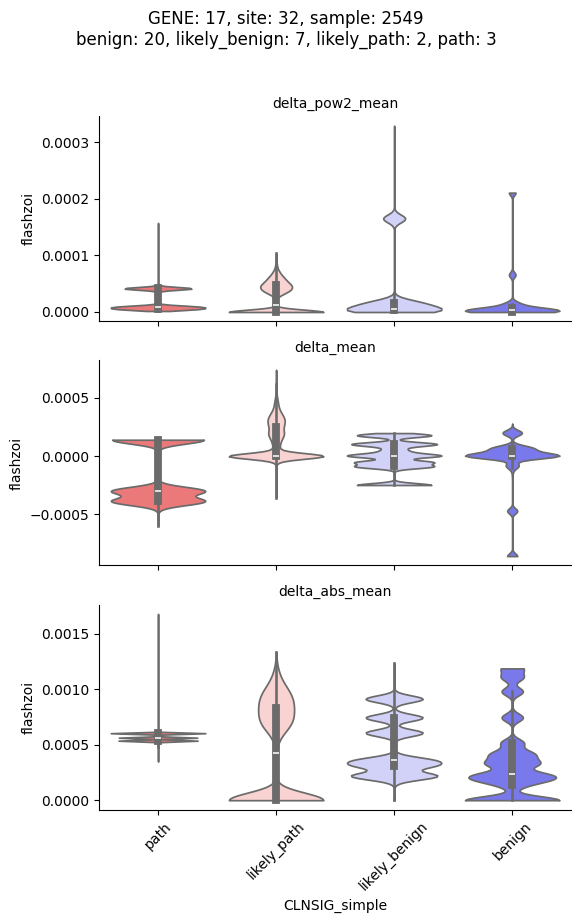

In [52]:
plot_violin(delta_df)

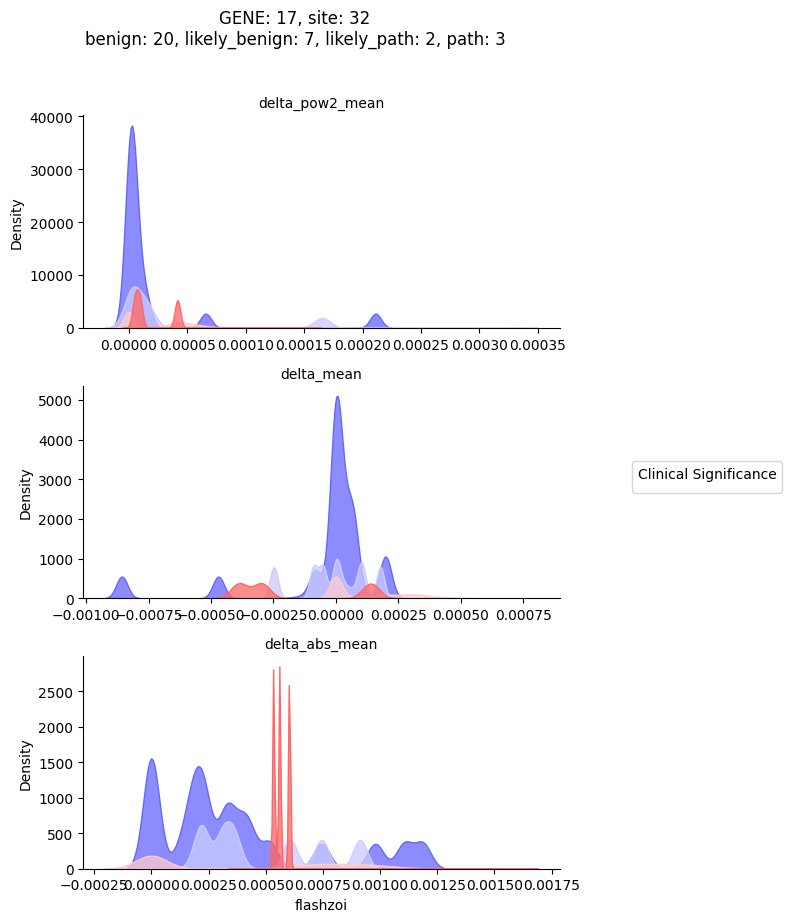

In [40]:
plot_kde(delta_df)

In [66]:
clnsig_simple_counts = delta_df.groupby("GENE")["CLNSIG_simple"].nunique().sort_values(ascending=False)
clnsig_simple_counts = clnsig_simple_counts.loc[clnsig_simple_counts>1]
clnsig_simple_counts

GENE
DMD       3
CHM       2
CSF2RA    2
SHOX      2
Name: CLNSIG_simple, dtype: int64

<string>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


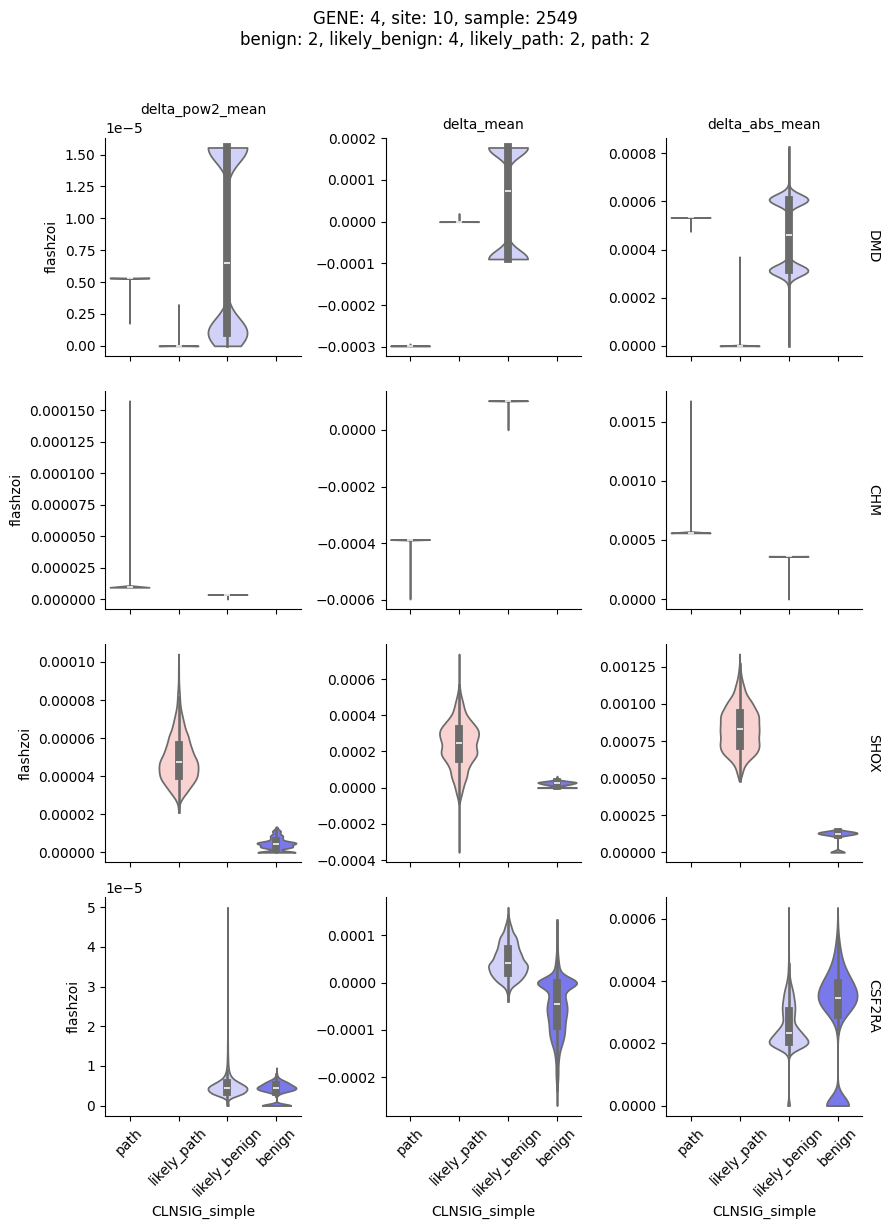

In [86]:
vep_select = delta_df.loc[delta_df["GENE"].isin(clnsig_simple_counts.index)]

g = plot_violin(vep_select, row="GENE")
